# **MULTI-HEAD ATTENTION ANALYSIS**

To investigate the interpretability of `TacticalBERT` model, this notebook implements a selector of retrieving specific match sequence and it does an analysis of the attention mechanism behavior across the four heads of the four layers of the model.

This notebook bases its analysis on the paper [*"Quantifying Attention Flow in Transformers" by Samira Abnar and Willem Zuidema (2020)*](https://arxiv.org/pdf/2005.00928). The authors address the **"Raw Attention Problem"**: in Transformers, information from input tokens becomes increasingly mixed across layers, making raw attention weights an unreliable proxy for the actual importance of token.

## **SETUP and DATA LOADING**

In [4]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
from mplsoccer import Pitch
import json
import sys
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

proj_root = Path.cwd().parent
sys.path.insert(0, str(proj_root))

from src.config import Config
from src.model import TacticalBert

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with open(Config.PROCESSED_DATA_DIR / "vocab.json", 'r') as f:
    vocabs = json.load(f)
type_vocab = vocabs['type_name']
id_to_action = {v: k for k, v in type_vocab.items()}

model = TacticalBert(vocab_size=len(type_vocab)).to(device)
model.load_state_dict(torch.load(Config.BEST_MODEL_PATH, map_location=device))
model.eval()


tokenized_sequences = torch.load(Config.PROCESSED_DATA_DIR / "dataset_tokenized.pt", weights_only=False)

def get_tactical_sequence(sequences, match_id=None, possession_id=None, min_len=10, last_action=None):
    """
    Selects a tactical sequence based on specified criteria:
    - If match_id and possession_id are provided, it tries to find that specific sequence.
    - If not found or not provided, it randomly selects a sequence that has at least 'min_len' events and optionally ends with 'last_action'.
    """
    
    if match_id is not None and possession_id is not None:
        selected = [s for s in sequences if s['match_id'] == match_id and s['possession_id'] == possession_id]
        if selected:
            return selected[0]
        else:
            print(f"Specific sequence not found. It will be selected randomly.")

    candidates = [s for s in sequences if len(s['type_ids']) >= min_len]
    
    if last_action is not None:
        candidates = [s for s in candidates if s['type_ids'][-1] == last_action]
        
    if not candidates:
        print("No sequences found matching the criteria. Returning a random sequence.")
        return random.choice(sequences)

    chosen = random.choice(candidates)
    return chosen

#Change the parameters to select a specific sequence 
selected_seq = get_tactical_sequence(tokenized_sequences, match_id=3825652, possession_id=79)

#If you want a random sequence with a fixed minimum length and ending with a specific action, use:
#shot_token = type_vocab['Shot']
#selected_seq = get_tactical_sequence(tokenized_sequences, min_len=12, last_action=shot_token)

print(f"Sequence selected from: Match {selected_seq['match_id']} | Possession {selected_seq['possession_id']}")
print(f"Length: {len(selected_seq['type_ids'])} events.")

Sequence selected from: Match 3825652 | Possession 79
Length: 14 events.


## **VISUALIZING TACTICAL CONTEXT**
This section provides a football pitch showing the sequence of passes, carrie and other actions. Understanding the spatial and sequential distribution could be crucial to later validate if specific attention heads are acting specifically for these cases.

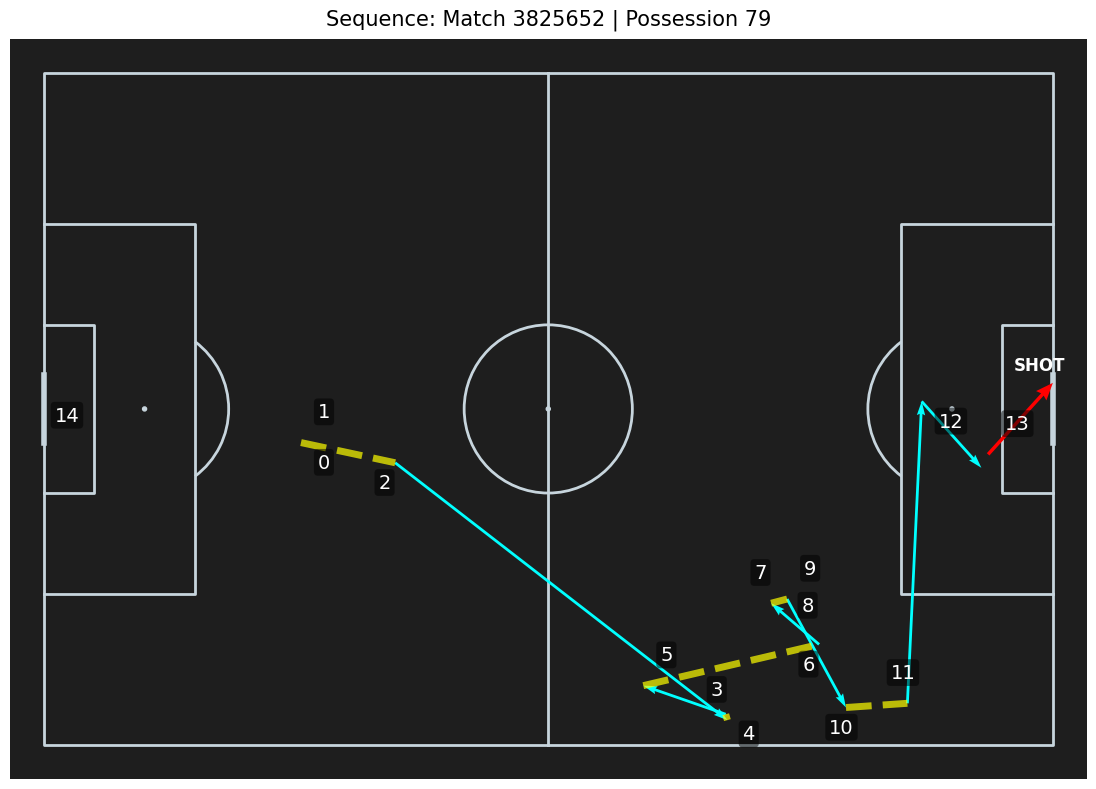

Extracted 15 events for this possession.


,type_name,under_pressure,x,y
0,Ball Recovery,NaN,30.6,44.0
1,Carry,NaN,30.6,44.0
2,Pass,NaN,41.8,46.4
3,Carry,NaN,81.3,77.0
4,Pass,NaN,81.1,76.3
5,Carry,NaN,71.3,72.9
6,Pass,NaN,92.2,68.0
7,Carry,1.0,86.5,63.1
8,Pressure,NaN,88.1,61.0
9,Pass,1.0,88.4,62.6


In [5]:
from mplsoccer import Pitch, Sbopen
import matplotlib.pyplot as plt

parser = Sbopen()

match_id = int(selected_seq['match_id'])
possession_id = int(selected_seq['possession_id'])

df_events, _, _, _ = parser.event(match_id)

# We select only the columns relevant for tactical visualization
filter_cols = [
    'type_name', 'possession', 
    'x', 'y', 'end_x', 'end_y', 
    'player_name', 'position_name', 'under_pressure',
]

# Create the filtered DataFrame for the specific possession
possession_df = df_events[filter_cols].copy()
possession_df = possession_df[possession_df['possession'] == possession_id].reset_index()

defensive_types = ['Pressure', 'Interception', 'Tackle', 'Clearance', 'Block', 'Duel']

# Exclude defensive action rows (handle NaNs) and reset index
possession_df = possession_df[~possession_df['type_name'].fillna('').isin(Config.IGNORED_EVENTS)].reset_index(drop=True)

#Mirror defensive actions for better visualization
def mirror_defensive_actions(row):
    if row['type_name'] in defensive_types:
        return 120 - row['x'], 80 - row['y'], 120 - row['end_x'], 80 - row['end_y']
    return row['x'], row['y'], row['end_x'], row['end_y']

possession_df[['x', 'y', 'end_x', 'end_y']] = possession_df.apply(mirror_defensive_actions, axis=1, result_type='expand')

pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e1e1e', line_color='#c7d5dd')
fig, ax = pitch.draw(figsize=(12, 8))

# Iterate through events to draw arrows (Passes or Shot) and lines (Carries)
for i, row in possession_df.iterrows():
    if row['type_name'] == 'Pass':
        pitch.arrows(row.x, row.y, row.end_x, row.end_y, 
                     color='#00ffff', ax=ax, width=2, headwidth=3, label='Pass' if i==0 else "")
    
    elif row['type_name'] == 'Carry':
        pitch.lines(row.x, row.y, row.end_x, row.end_y, 
                    color='#ffff00', ax=ax, ls='--', alpha=0.7, label='Carry' if i==0 else "")
    
    elif row['type_name'] == 'Ball Receipt':
        pitch.scatter(row.x, row.y, 
                    color='#ff00ff', ax=ax, ls='-.', alpha=0.7, label='Dribble' if i==0 else "")
        
    elif row['type_name'] == 'Shot':
        pitch.arrows(row.x, row.y, row.end_x, row.end_y, 
                     color='#ff0000', ax=ax, width=2.5, headwidth=4, label='Shot' if i==0 else "")
        ax.text(row.x+3, row.y - 10 , "SHOT", color='white', fontweight='bold', fontsize=12)

    offset_y = 3 if i % 2 == 0 else -3
    offset_x = 2 if (i // 2) % 2 == 0 else -2

    ax.text(row.x + offset_x, row.y + offset_y, str(i), 
            color='white', 
            fontsize=14,
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))


plt.title(f"Sequence: Match {match_id} | Possession {possession_id}", 
          color='black', fontsize=15, pad=10)
plt.show()

print(f"Extracted {len(possession_df)} events for this possession.")
display(possession_df[['type_name', 'under_pressure', 'x', 'y']])

## **RAW SELF-ATTENTION MATRICES**

This section is limited to examining the model's **Raw Attention** weights. In the Transformer architecture, each attention head computes a self-attention matrix that dictates how much focus a token places on every other token at that specific depth.

The following cell visualizes the matrices across all the layers of the model, allowing to observe the immediate, layer-specific token dependencies and identify obvious patterns (such as recency bias or broad contextual aggregation).

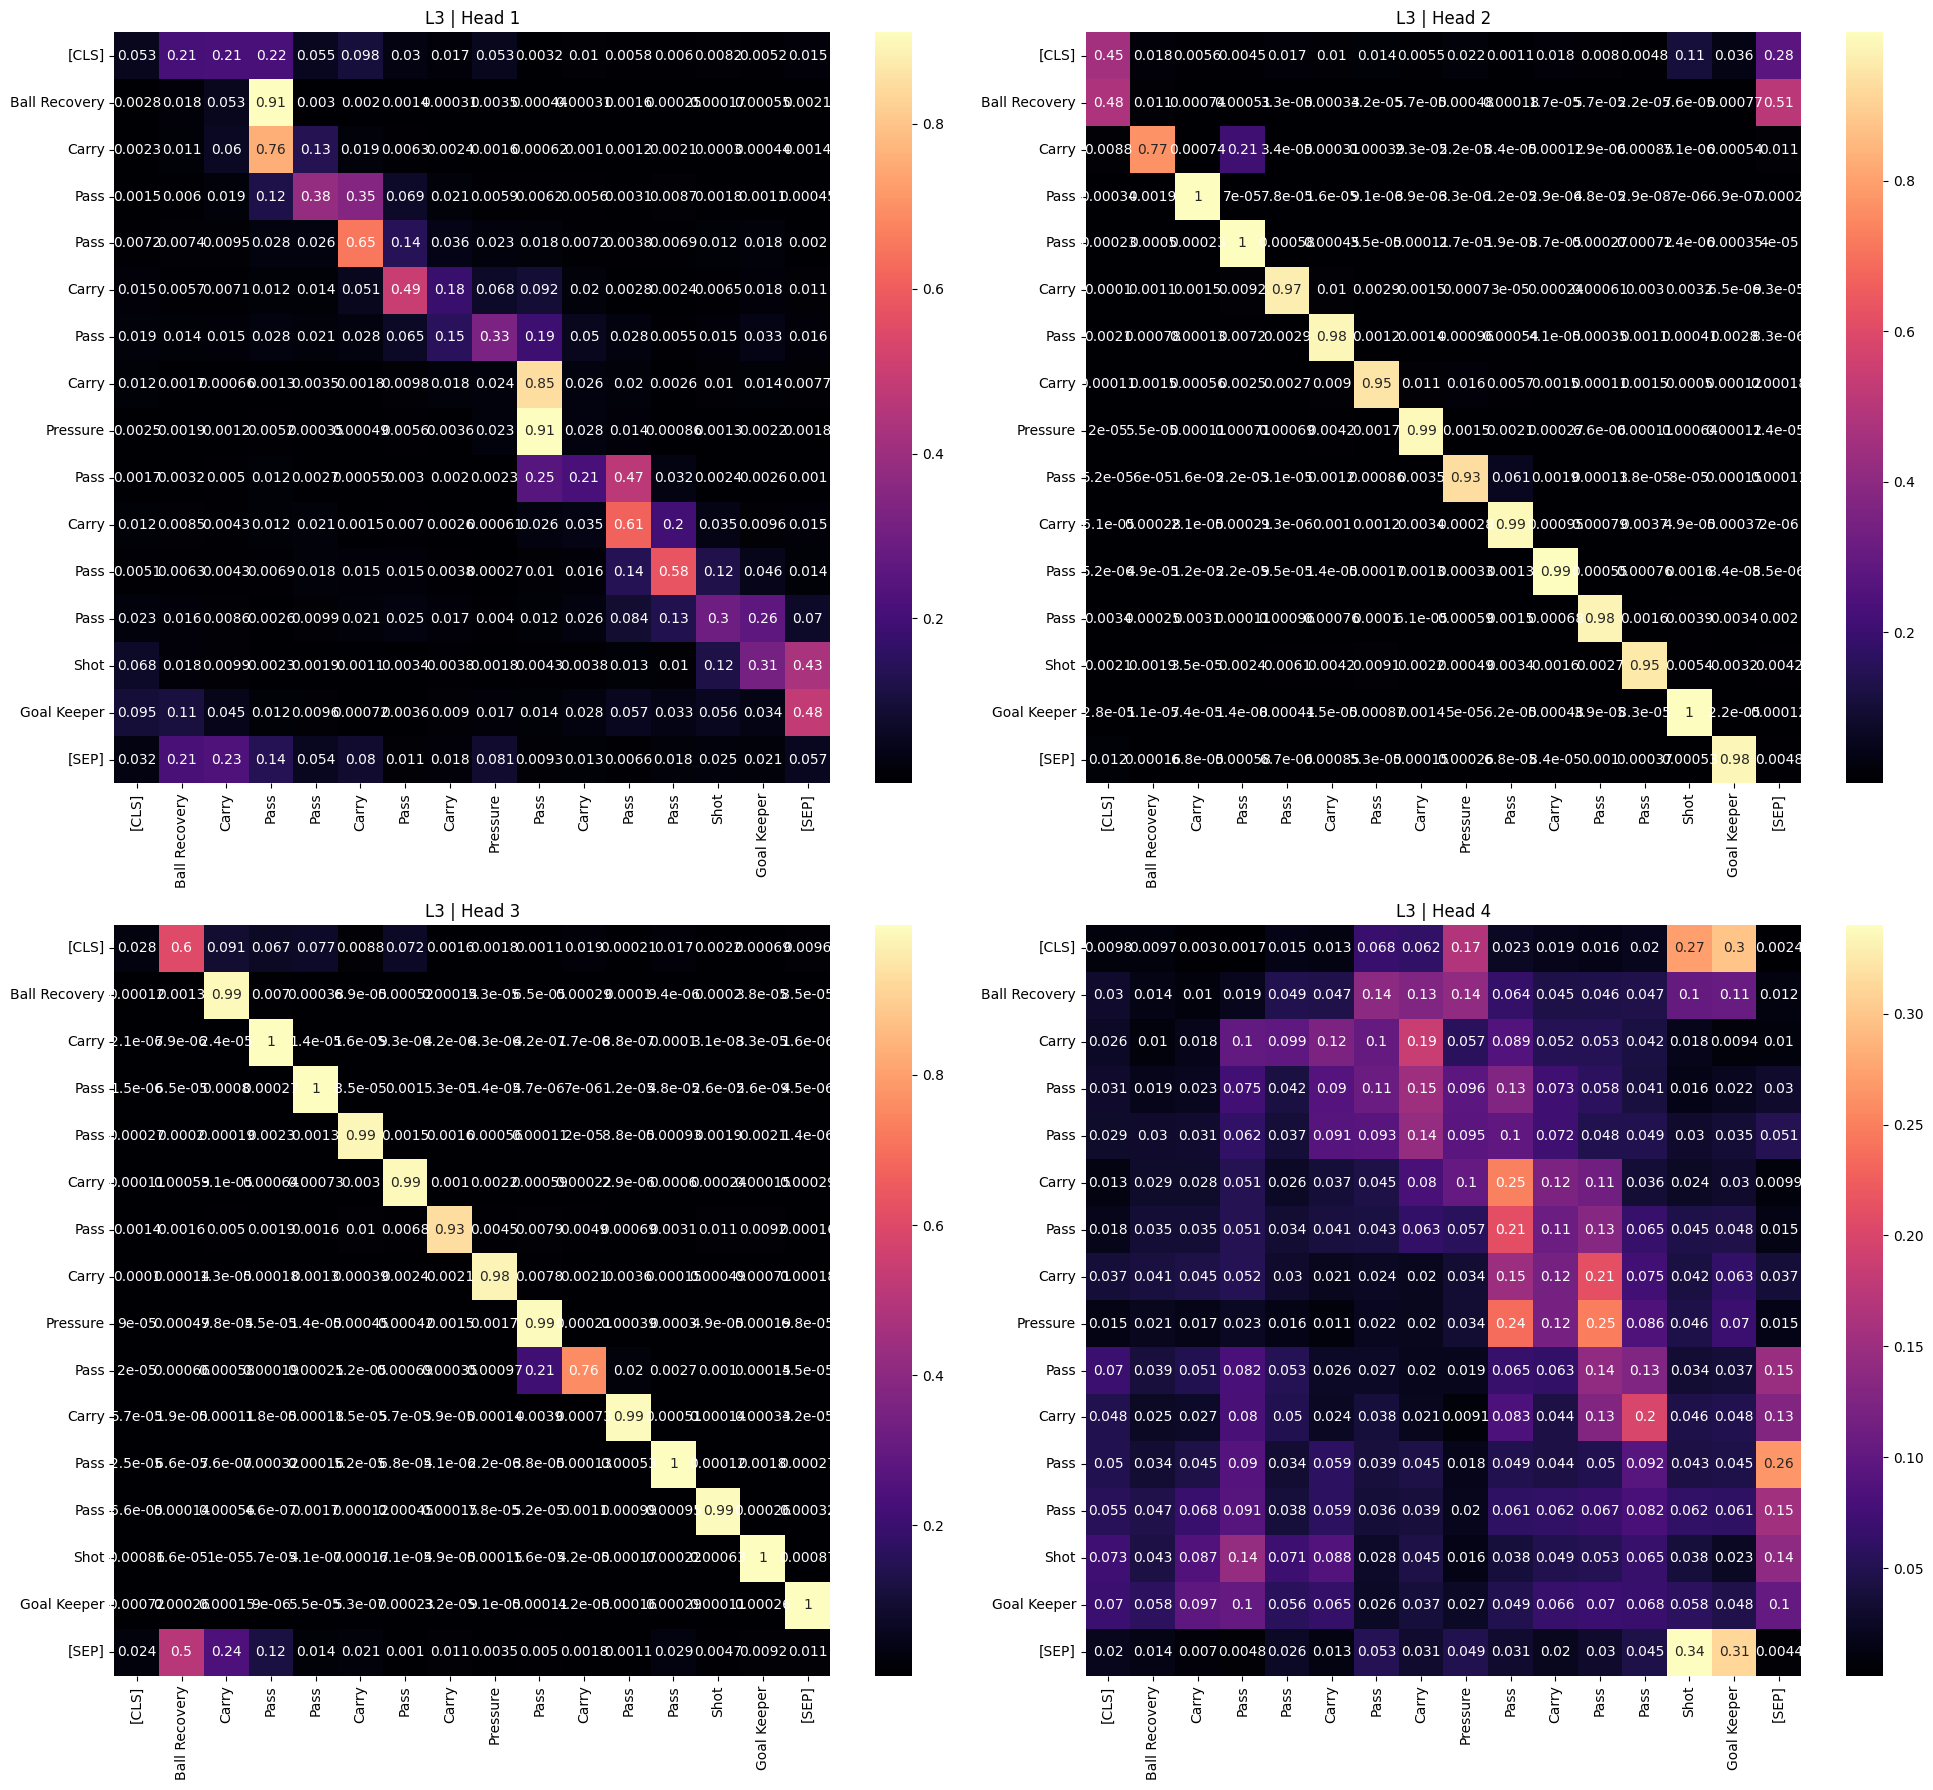

In [6]:
def analyze_heads_specialization(model, sequence, layer_to_probe):
    # Preparing tensors for the model (Adding CLS/SEP tokens and padding)
    type_ids = torch.tensor([type_vocab["[CLS]"]] + sequence['type_ids'] + [type_vocab["[SEP]"]]).unsqueeze(0).to(device)
    loc_ids = torch.tensor([0] + sequence['loc_ids'] + [0]).unsqueeze(0).to(device)
    dur_ids = torch.tensor([0] + sequence['duration_ids'] + [0]).unsqueeze(0).to(device)
    
    ctx_raw = [[0,0,0]] + sequence['context_features'] + [[0,0,0]]
    ctx = torch.tensor(ctx_raw, dtype=torch.float).unsqueeze(0).to(device)
    
    mask = torch.ones(type_ids.shape).to(device)
    
    with torch.no_grad():
        outputs = model(type_ids, mask, loc_ids=loc_ids, duration_ids=dur_ids, context_features=ctx, output_attentions=True)
    
    attentions = outputs.attentions
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    axes = axes.flatten()
    
    event_names = ["[CLS]"] + [id_to_action[i] for i in sequence['type_ids']] + ["[SEP]"]

    for h in range(4):
        attn_matrix = attentions[layer_to_probe][0, h].cpu().numpy()
        sns.heatmap(attn_matrix, annot=True, cmap="magma", ax=axes[h], cbar=True,
                    xticklabels=event_names, yticklabels=event_names)
        axes[h].set_title(f"L{layer_to_probe+1} | Head {h+1}")

    plt.tight_layout()
    plt.show()

#Change the parameter to analyze the 4 heads of a specific layer
attention_layer = 2 #(0-indexed)
analyze_heads_specialization(model, selected_seq, attention_layer)

Rather than just observing heatmaps, the section below implements an **Head Profiler** to quantify head behavior using specific metrics:

- **Attention entropy**: the average Shannon entropy of the attention distribution across real events. A low entropy indicates a highly specialized head that focuses on specific events. A high entropy indicates a global observer that diffuses its attention broadly to gather general context.

- **Attention span**: the average temporal distance (in sequence steps) between the current event and the past events it attends to. A low span reacts only to recent, short-term events. A high span reveals a long-range tactical memory.

- **Gini**: an adaptation of the economic measure of wealth inequality, applied to the distribution of attention weights. A high Gini coefficient means high sparsity: the head assigns almost all importance to a single token, ignoring the rest. A low Gini indicates a more "democratic" spread, meaning the head requires a combination of multiple events to extract meaning.

- **Sequential score**: the average attention weight placed exactly on the immediately preceding event (t−1), represented by the lower diagonal of the attention matrix. High sequential scores define the heads that maintain the timeline and process the step-by-step physical chain of the play.

- **Spatial spread**: the physical dispersion, calculated as the weighted standard deviation of the pitch coordinates (x,y) that the head attends to. A low spatial spread means the head is a "Zone Analyst," exclusively monitoring events in a tight, localized area of the pitch. A high spatial spread means the head tracks the ball across large distances globally.

- **Pressure sensitivity**: the average attention weight directed towards events that occurred while the acting player was flagged as 'under pressure'. Identifies heads with high sensitivity specialize in understanding contested situations, helping the model evaluate how defensive pressure disrupts or shapes the attacking outcome.


In [7]:
import torch
import numpy as np
import pandas as pd


def calculate_full_head_metrics(model, sequence, possession_df):

    type_ids = torch.tensor([type_vocab["[CLS]"]] + sequence['type_ids'] + [type_vocab["[SEP]"]]).unsqueeze(0).to(device)
    loc_ids = torch.tensor([0] + sequence['loc_ids'] + [0]).unsqueeze(0).to(device)
    dur_ids = torch.tensor([0] + sequence['duration_ids'] + [0]).unsqueeze(0).to(device)
    ctx_raw = [[0,0,0]] + sequence['context_features'] + [[0,0,0]]
    ctx = torch.tensor(ctx_raw, dtype=torch.float).unsqueeze(0).to(device)
    mask = torch.ones(type_ids.shape).to(device)

    pressure_indices = [i for i, c in enumerate(ctx_raw) if c[0] == 1]

    xs = np.array([0] + list(possession_df['x'].values))
    ys = np.array([0] + list(possession_df['y'].values))
        
    with torch.no_grad():
        outputs = model(type_ids, mask, loc_ids=loc_ids, duration_ids=dur_ids, context_features=ctx, output_attentions=True)
    
    attentions = outputs.attentions
    num_layers, num_heads = len(attentions), attentions[0].shape[1]
    seq_len = type_ids.shape[1]
    real_event_range = range(1, seq_len - 1)
    
    head_data = []

    for l in range(num_layers):
        for h in range(num_heads):
            attn = attentions[l][0, h].cpu().numpy()
            
            #Entropy
            eps = 1e-10
            entropies = -np.sum(attn[real_event_range] * np.log(attn[real_event_range] + eps), axis=-1)
            avg_entropy = np.mean(entropies)

            #Span and Spatial
            spans = []
            spatial_spreads = []
            for i in real_event_range:
                row = attn[i]
                distances = np.array([max(0, i - j) for j in range(seq_len)])
                spans.append(np.sum(row * distances))

                weighted_x_mean = np.sum(row * xs)
                weighted_y_mean = np.sum(row * ys)
                
                var_x = np.sum(row * (xs - weighted_x_mean)**2)
                var_y = np.sum(row * (ys - weighted_y_mean)**2)
                
                spatial_spreads.append(np.sqrt(var_x + var_y + eps))
            avg_span = np.mean(spans)
            avg_spatial = np.mean(spatial_spreads)

            seq_score = np.mean(np.diag(attn, k=-1)[0:len(real_event_range)-1])

            #Pressure Sensitivity
            if pressure_indices:
                press_attn = attn[real_event_range][:, pressure_indices].mean()
            else:
                press_attn = 0

            head_data.append({
                'ID': f"L{l+1}_H{h+1}",
                'Layer': l + 1,
                'Head': h + 1,
                'Entropy': round(avg_entropy, 3),
                'Span': round(avg_span, 2),
                'Sequential': round(seq_score, 3),
                'Spatial': round(avg_spatial, 2),
                'Press_Sens': round(press_attn, 3)
            })

    return pd.DataFrame(head_data)

df_metrics = calculate_full_head_metrics(model, selected_seq, possession_df)
df_metrics_styled = df_metrics.style.format({
    'Entropy': '{:.3f}',
    'Span': '{:.2f}',
    'Gini': '{:.3f}',
    'Sequential': '{:.3f}',
    'Spatial': '{:.2f}',
    'Press_Sens': '{:.3f}'
}).background_gradient(cmap='magma')
display(df_metrics_styled)

,ID,Layer,Head,Entropy,Span,Sequential,Spatial,Press_Sens
0,L1_H1,1,1,2.248,1.79,0.202,34.18,0.076
1,L1_H2,1,2,2.594,2.12,0.059,40.51,0.054
2,L1_H3,1,3,2.672,2.73,0.054,41.52,0.053
3,L1_H4,1,4,2.635,2.39,0.076,39.68,0.051
4,L2_H1,2,1,0.348,0.10,0.007,10.35,0.072
5,L2_H2,2,2,0.669,1.10,0.753,11.13,0.105
6,L2_H3,2,3,2.473,2.06,0.059,39.34,0.046
7,L2_H4,2,4,2.431,1.67,0.040,38.97,0.051
8,L3_H1,3,1,1.360,0.64,0.020,23.22,0.101
9,L3_H2,3,2,0.227,0.97,0.920,6.01,0.074


From the data it's possible to group heads in different categories and to do some observations:

- [ High **Sequential**, Low **Entropy** and **Span** ] as L3_H2 and L2_H2: they are the equivalent to positional/syntax in the natural language are focused exclusively on the immediately preceding event.

- [High **Entropy** and **Spatial**] as L1 heads: they are the global observers, they don't make specific tactical decisions. They are looking almost everywhere and their function is to read the whole pitch.

- [Low **Sequential**, **Entropy**, **Span**] as L2_H1 and L3_H3: they have chosen a single point to stare at, but it's not the preceding event. With low sequential and near-zero backward span they are often attending to the future event. These heads evaluate the immediate consequence of an action.

- The max value of **Span** is in the first layer, it means that long-range tactical information is compressed and mixed in the first layers. 

- The model does not ignore defensive **Pressure**; it simply absorbs it early. Transformers process low-level features in their initial layers. By Layer 1, a standard 'Pass' is already contextually embedded as a 'Pressured Pass'. Consequently, deeper layers (like Layer 4) do not need to explicitly attend to the pressure indicator, as the information is already intrinsic to the token's vector.

## **FUTURE RELATED WORKS**

The analysis of Raw Attention permits to understand the internal division of labor and trying to understand the specialized roles of individual heads. However, as demonstrated by Abnar & Zuidema (2020), examining raw attention weights in isolation is insufficient for tracking the true impact of an early event on the final prediction. This limitation arises because residual connections and continuous token mixing across layers obscure the original signal. 

Future iterations of this notebook would be implementing more advanced interpretability techniques that quantify the global propagation of information throughout the entire network:

- **Attention Rollout**: to track how information is propagated from the input tokens through the layers by assuming a linear combination of attention weights.

- **Attention Flow**: treating the transformer as a flow network to compute the maximum flow between input and output.